<a href="https://colab.research.google.com/github/ProfessorPatrickSlatraigh/cis9557__baseline/blob/main/CIS9557_K_NearestNeighbors_Social_Network_Ads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CIS9557 - Business Analytics**

## **Module 06 - Similarity and Clustering**
### **Nearest-Neighbor Classification**
*with Python and scikit-learn*

**Dataset:** Social_Network_Ads.csv
*Sourced from Professor Patrick's GitHub data repository*
  
<i>a copy of this notebook is available online at [bit.ly/cis9557kNearestNeighbor](https://bit.ly/cis9557kNearestNeighbor)</i>

---

**This notebook has four sections:**

1. Loading and Exploring the Dataset
2. Preparing Features for Distance Calculation
3. Building and Evaluating a K-Nearest Neighbor Classifier
4. The Effect of K: Local vs. General Predictions

---

## Background: Nearest-Neighbor Classification

In the lecture, we established that much of managerial reasoning is implicitly comparative. When a loan officer evaluates an application, they are drawing on experience with past applicants. When a marketing analyst decides whether to target a customer, they are asking: does this person resemble customers who responded before?

The **K-Nearest Neighbor (KNN)** algorithm makes that comparative logic explicit. To classify a new, unlabeled observation, the model:

1. Measures the distance from the new observation to every labeled observation in the training data
2. Identifies the K observations that are closest (the K nearest neighbors)
3. Predicts the majority class among those K neighbors

No explicit model is constructed. The training data itself is the model.

In this notebook, the business question is: **given a social network user's age and estimated salary, will they purchase a product after seeing an advertisement?** The target variable is binary: Purchased (1) or Not Purchased (0).

---

## Section 1: Loading and Exploring the Dataset

### Load a copy of the dataset from Professor Patrick's GitHub repository

In [1]:
!curl 'https://raw.githubusercontent.com/ProfessorPatrickSlatraigh/data/main/Social_Network_Ads.csv' -o Social_Network_Ads.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4903  100  4903    0     0  29804      0 --:--:-- --:--:-- --:--:-- 29896


### Import required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

### Read the dataset and inspect its structure

In [3]:
ads = pd.read_csv('Social_Network_Ads.csv')
ads.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


The dataset contains three columns:

- **Age**: The user's age in years. This is a numeric feature.
- **EstimatedSalary**: An estimate of the user's annual salary in local currency units. This is a numeric feature.
- **Purchased**: The target variable. A value of 1 indicates the user purchased the product after viewing the advertisement; 0 indicates they did not.

For this demonstration, the two numeric features **Age** and **EstimatedSalary** will serve as inputs. Using exactly two features allows the model's decision boundary to be plotted in two dimensions, which makes the KNN mechanism directly visible.

In [4]:
print('Dataset dimensions:', ads.shape)
print()
print('Target variable distribution:')
print(ads['Purchased'].value_counts())
print()
print('Purchase rate: {:.1f}%'.format(ads['Purchased'].mean() * 100))

Dataset dimensions: (400, 3)

Target variable distribution:
Purchased
0    257
1    143
Name: count, dtype: int64

Purchase rate: 35.8%


### Visualize the raw data

Before building any model, it is useful to plot the data and observe whether any natural separation exists between purchasers and non-purchasers.

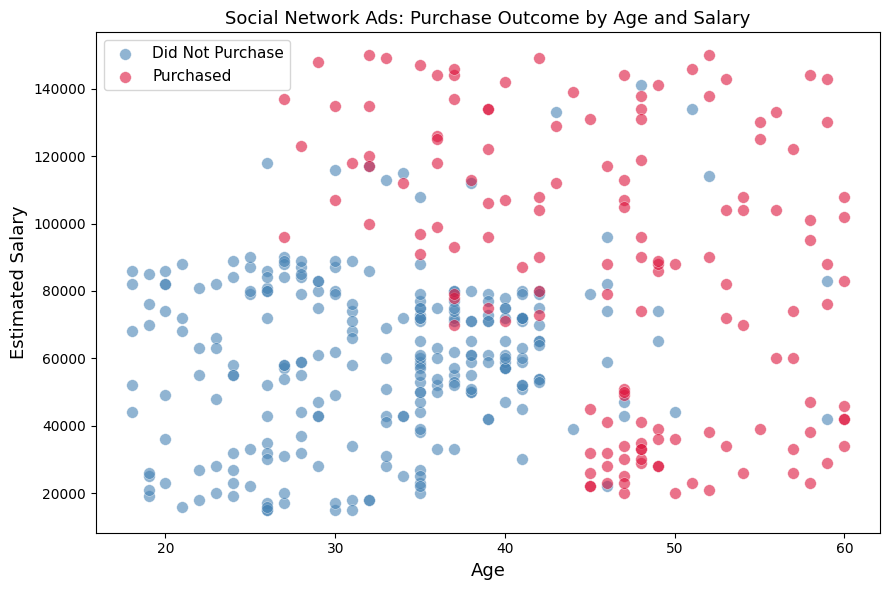

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {0: 'steelblue', 1: 'crimson'}
labels = {0: 'Did Not Purchase', 1: 'Purchased'}

for outcome in [0, 1]:
    subset = ads[ads['Purchased'] == outcome]
    ax.scatter(
        subset['Age'],
        subset['EstimatedSalary'],
        c=colors[outcome],
        label=labels[outcome],
        alpha=0.6,
        edgecolors='white',
        linewidths=0.4,
        s=70
    )

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Estimated Salary', fontsize=13)
ax.set_title('Social Network Ads: Purchase Outcome by Age and Salary', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The scatter plot reveals that purchase behavior is not random with respect to age and salary. Older users and users with higher salaries tend to cluster among purchasers, while younger users with lower salaries tend not to purchase. The boundary between the two groups is not perfectly clean, which is where the classifier adds value: it finds the pattern in the data and applies it systematically to new observations.

---

## Section 2: Preparing Features for Distance Calculation

KNN computes the Euclidean distance between observations. If the two features are measured on very different numeric scales, the feature with the larger range will dominate the distance calculation regardless of its actual predictive value.

In this dataset:
- **Age** ranges from approximately 18 to 60 (a spread of roughly 42 units)
- **EstimatedSalary** ranges from roughly 15,000 to 150,000 (a spread of roughly 135,000 units)

Without rescaling, a difference of 10,000 salary units would dwarf any age difference, and the model would effectively make decisions almost entirely on salary. This does not reflect a deliberate business judgment; it is an artifact of units.

**Feature scaling** (also called normalization or standardization) transforms each feature so that it has a mean of zero and a standard deviation of one. After scaling, both features contribute comparably to the distance calculation.

> *This is one of the points at which the analyst's judgment matters most: the decision to scale, and which features to include, encodes assumptions about what similarity means in this business context.*

### Select features and target, then split into training and test sets

In [6]:
# Select the two numeric features and the binary target
X = ads[['Age', 'EstimatedSalary']].values
y = ads['Purchased'].values

# Reserve 25% of the data for testing; the model will never see this data during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print('Training observations:', X_train.shape[0])
print('Test observations:    ', X_test.shape[0])

Training observations: 300
Test observations:     100


The holdout (test) set plays the same role here as in any supervised model: it provides an unbiased estimate of how the model will perform on observations it has not seen. Performance on training data alone is not a reliable indicator of how the model will behave when deployed.

### Apply feature scaling

In [7]:
scaler = StandardScaler()

# Fit the scaler on training data only, then transform both sets
# This prevents information from the test set from influencing the scaling parameters
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Before scaling -- Age range in training set:    {:.0f} to {:.0f}'.format(
    X_train[:, 0].min(), X_train[:, 0].max()))
print('Before scaling -- Salary range in training set: {:.0f} to {:.0f}'.format(
    X_train[:, 1].min(), X_train[:, 1].max()))
print()
print('After scaling  -- Age range in training set:    {:.2f} to {:.2f}'.format(
    X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max()))
print('After scaling  -- Salary range in training set: {:.2f} to {:.2f}'.format(
    X_train_scaled[:, 1].min(), X_train_scaled[:, 1].max()))

Before scaling -- Age range in training set:    18 to 60
Before scaling -- Salary range in training set: 15000 to 150000

After scaling  -- Age range in training set:    -1.94 to 2.19
After scaling  -- Salary range in training set: -1.60 to 2.34


Both features are now expressed in comparable units. The distance calculation will treat a one-unit difference in scaled Age as equivalent to a one-unit difference in scaled Salary.

---

## Section 3: Building and Evaluating a K-Nearest Neighbor Classifier

### What the algorithm does

When asked to classify a new user (for example, Age = 35, EstimatedSalary = 72,000), the KNN classifier:

1. Scales the new user's features using the same scaler fitted on training data
2. Computes the Euclidean distance from this user to every user in the training set
3. Identifies the K training users who are closest
4. Counts how many of those K neighbors purchased (Purchased = 1) and how many did not
5. Predicts the majority class

The value of K is a tuning decision. A small K (for example, K = 1) makes the model highly sensitive to local patterns and individual observations. A larger K smooths over local variation and produces more stable but potentially less precise predictions.

### Fit a KNN classifier with K = 5

In [12]:
# Instantiate and fit the classifier
# metric='minkowski' with p=2 is equivalent to Euclidean distance
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

Note that `fit()` stores the training data; no parameters are estimated in the traditional sense. The training data itself constitutes the model.

### Classify an individual observation

Before evaluating performance across the full test set, it is instructive to trace through a single prediction to make the KNN mechanism concrete.

In [13]:
# A new user: Age 42, Estimated Salary 87,000
new_user = pd.DataFrame({'Age': [42], 'EstimatedSalary': [87000]})
new_user_scaled = scaler.transform(new_user[['Age', 'EstimatedSalary']].values)

# Predict class and retrieve the 5 nearest neighbors
prediction = knn.predict(new_user_scaled)
distances, indices = knn.kneighbors(new_user_scaled)

print('New user: Age = 42, Estimated Salary = 87,000')
print()
print('5 nearest neighbors in the training set:')
neighbor_df = pd.DataFrame({
    'Age':             X_train[indices[0], 0],
    'EstimatedSalary': X_train[indices[0], 1],
    'Purchased':       y_train[indices[0]],
    'Distance (scaled)': distances[0].round(3)
})
print(neighbor_df.to_string(index=False))
print()
print('Majority class among neighbors: Purchased =', prediction[0])
print('Prediction:', 'WILL PURCHASE' if prediction[0] == 1 else 'WILL NOT PURCHASE')

New user: Age = 42, Estimated Salary = 87,000

5 nearest neighbors in the training set:
 Age  EstimatedSalary  Purchased  Distance (scaled)
  41            87000          1              0.098
  42            80000          1              0.204
  42            79000          0              0.234
  41            79000          0              0.253
  40            78000          0              0.328

Majority class among neighbors: Purchased = 0
Prediction: WILL NOT PURCHASE


This output traces the full reasoning path. The five most similar training users are identified by their scaled distance to the new user. The majority outcome among those five neighbors becomes the prediction. There is no formula, coefficient, or rule; the prediction follows entirely from the stored training data and the chosen distance metric.

### Evaluate performance on the holdout test set

In [14]:
y_pred = knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print('Confusion Matrix (K = 5):')
print()
print('                 Predicted: No   Predicted: Yes')
print('Actual: No       {:>10}   {:>13}'.format(cm[0, 0], cm[0, 1]))
print('Actual: Yes      {:>10}   {:>13}'.format(cm[1, 0], cm[1, 1]))
print()
print('Accuracy on test set: {:.1f}%'.format(acc * 100))
print()
print('True Positives  (correctly predicted purchase):      ', cm[1, 1])
print('True Negatives  (correctly predicted no purchase):   ', cm[0, 0])
print('False Positives (predicted purchase, did not):       ', cm[0, 1])
print('False Negatives (predicted no purchase, did buy):    ', cm[1, 0])

Confusion Matrix (K = 5):

                 Predicted: No   Predicted: Yes
Actual: No               59               4
Actual: Yes               3              34

Accuracy on test set: 93.0%

True Positives  (correctly predicted purchase):       34
True Negatives  (correctly predicted no purchase):    59
False Positives (predicted purchase, did not):        4
False Negatives (predicted no purchase, did buy):     3


The confusion matrix is the most informative single summary of classifier performance. For a business application, the costs of false positives and false negatives are rarely symmetric:

- A **false positive** here means targeting a user who would not have purchased. The cost is wasted advertising spend.
- A **false negative** means failing to target a user who would have purchased. The cost is a missed revenue opportunity.

Which error is more costly depends on the business context -- and the answer to that question should inform how the model is used, not just whether its overall accuracy meets a threshold.

### Visualize the decision boundary

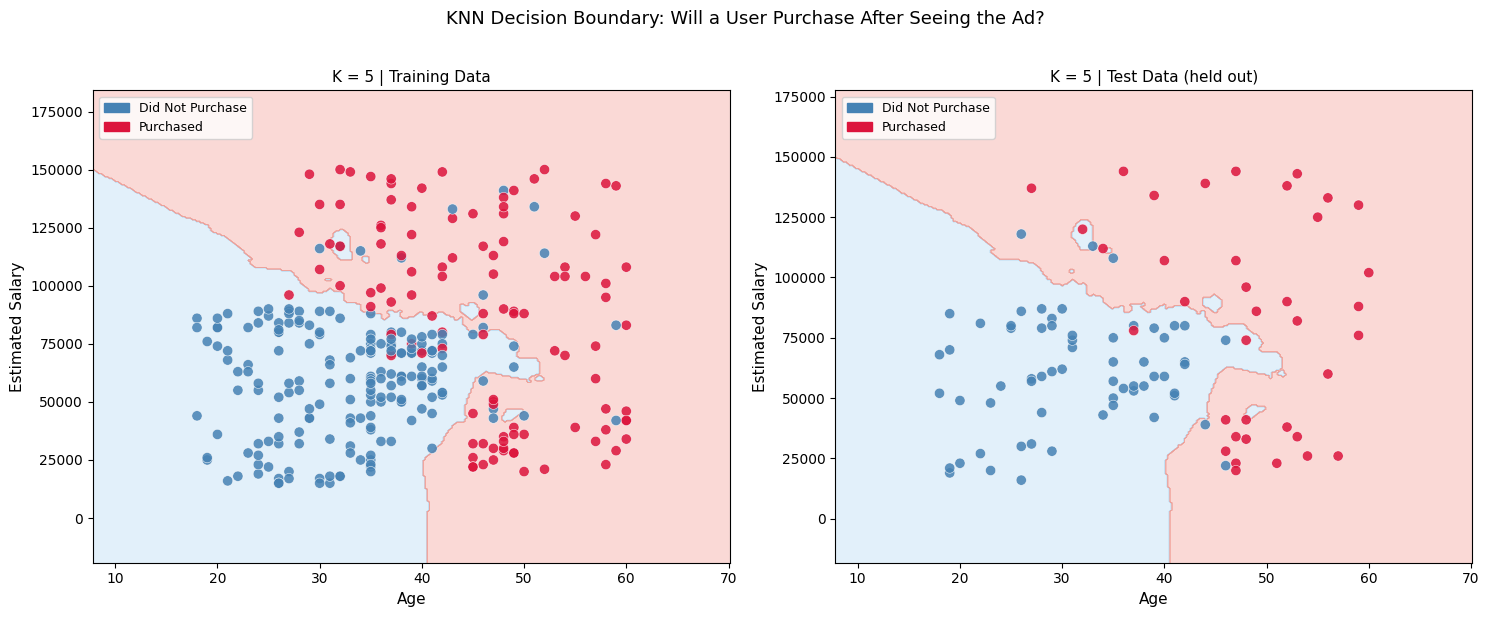

In [15]:
def plot_decision_boundary(model, X_scaled, y, scaler, title, ax):
    """
    Plot the KNN decision boundary in the original (unscaled) feature space.
    The boundary shows which regions of Age x Salary space the model predicts
    as 'Will Purchase' vs. 'Will Not Purchase'.
    """
    # Build a dense grid in scaled space
    h = 0.02
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Convert grid back to original scale for axis labeling
    grid_original = scaler.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
    age_grid   = grid_original[:, 0].reshape(xx.shape)
    salary_grid = grid_original[:, 1].reshape(xx.shape)

    X_original = scaler.inverse_transform(X_scaled)

    cmap_bg   = ListedColormap(['#AED6F1', '#F1948A'])
    cmap_pts  = ListedColormap(['steelblue', 'crimson'])

    ax.contourf(age_grid, salary_grid, Z, alpha=0.35, cmap=cmap_bg)
    ax.scatter(X_original[:, 0], X_original[:, 1],
               c=y, cmap=cmap_pts, edgecolors='white',
               linewidths=0.4, s=55, alpha=0.85)

    ax.set_xlabel('Age', fontsize=11)
    ax.set_ylabel('Estimated Salary', fontsize=11)
    ax.set_title(title, fontsize=11)

    patch_no  = mpatches.Patch(color='steelblue', label='Did Not Purchase')
    patch_yes = mpatches.Patch(color='crimson',   label='Purchased')
    ax.legend(handles=[patch_no, patch_yes], fontsize=9, loc='upper left')


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundary(
    knn, X_train_scaled, y_train, scaler,
    'K = 5 | Training Data', axes[0]
)
plot_decision_boundary(
    knn, X_test_scaled, y_test, scaler,
    'K = 5 | Test Data (held out)', axes[1]
)

plt.suptitle(
    'KNN Decision Boundary: Will a User Purchase After Seeing the Ad?',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

The shaded regions represent what the model predicts for every possible combination of age and salary. The blue region represents the area the model classifies as "will not purchase"; the red region represents "will purchase".

Key observations:
- The boundary is not a straight line. KNN produces a flexible, locally adaptive boundary that traces the structure of the training data.
- The right panel shows the same boundary applied to the test set. Misclassified points appear as dots whose color does not match the background region behind them.
- The boundary's shape will change as K changes. That is the subject of Section 4.

---

## Section 4: The Effect of K -- Local vs. General Predictions

### Why K matters

The choice of K controls how local or global the model's predictions are:

- **Small K (e.g., K = 1):** Every prediction is based on a single neighbor. The model traces the training data very closely, capturing fine-grained local patterns but also reacting strongly to noise and atypical cases. This is the highest-variance setting.
- **Large K (e.g., K = 25):** Every prediction is based on a larger neighborhood. The model produces smoother, more stable predictions that are less reactive to individual training points. This is the highest-bias setting.
- **Intermediate K:** Balances local sensitivity against global stability.

There is no universally correct value of K. The appropriate choice depends on the structure of the data and, in a business context, on how much local variation is meaningful versus how much is noise.

### Compare decision boundaries across three values of K

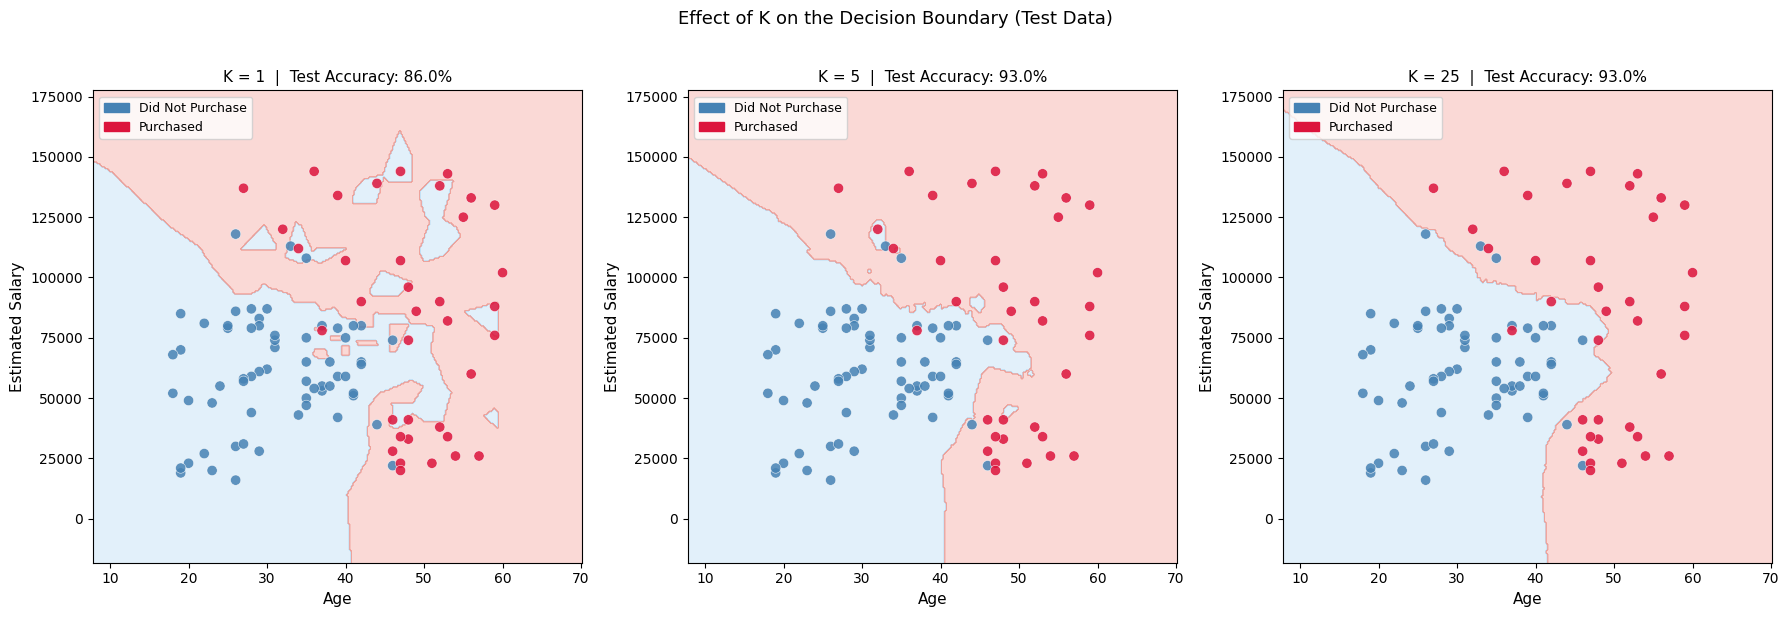

In [16]:
k_values = [1, 5, 25]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, k in zip(axes, k_values):
    model_k = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    model_k.fit(X_train_scaled, y_train)
    y_pred_k = model_k.predict(X_test_scaled)
    acc_k = accuracy_score(y_test, y_pred_k)

    plot_decision_boundary(
        model_k, X_test_scaled, y_test, scaler,
        'K = {}  |  Test Accuracy: {:.1f}%'.format(k, acc_k * 100),
        ax
    )

plt.suptitle(
    'Effect of K on the Decision Boundary (Test Data)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

### Compare accuracy and error rates across a wider range of K values

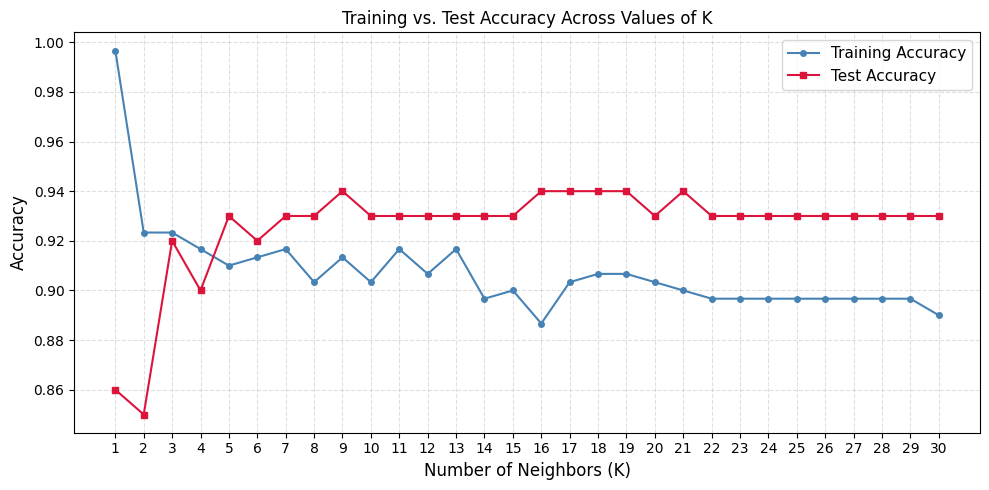

Highest test accuracy: 94.0% at K = 9


In [17]:
k_range = range(1, 31)
train_accuracies = []
test_accuracies  = []

for k in k_range:
    model_k = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    model_k.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, model_k.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test,  model_k.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, train_accuracies, label='Training Accuracy',
        marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.plot(k_range, test_accuracies,  label='Test Accuracy',
        marker='s', markersize=4, linewidth=1.5, color='crimson')
ax.set_xlabel('Number of Neighbors (K)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Training vs. Test Accuracy Across Values of K', fontsize=12)
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

best_k = k_range[test_accuracies.index(max(test_accuracies))]
print('Highest test accuracy: {:.1f}% at K = {}'.format(
    max(test_accuracies) * 100, best_k))

### Reading the accuracy chart

At **K = 1**, the training accuracy reaches 100%. This is expected: when a model is asked to classify a training observation using its single nearest neighbor, that neighbor is the observation itself, so every prediction is correct. This does not indicate a good model; it indicates a model that has memorized the training data and will not generalize reliably to new cases. This is **overfitting**.

As K increases, training accuracy decreases while test accuracy initially improves. The point at which test accuracy peaks represents a reasonable balance between local sensitivity and generalization. Beyond that point, test accuracy typically declines as the model becomes too general and loses the ability to capture meaningful local patterns.

This chart is the KNN equivalent of the elbow plot introduced in the clustering section: it provides a diagnostic, not a definitive answer. The final choice of K should account for model performance alongside business judgment about how much local variation is meaningful in the specific application context.

---

## Summary

This notebook has demonstrated the following concepts from the lecture:

| Concept | What the Notebook Demonstrated |
|---|---|
| Similarity as the basis for classification | Neighbors identified by scaled Euclidean distance |
| Feature scaling as a business decision | Before-and-after comparison of Age and Salary ranges |
| The KNN mechanism | Step-by-step trace of a single prediction with neighbor table |
| Train/test split as quality control | Accuracy reported on held-out data, not training data |
| The confusion matrix | False positives and false negatives interpreted in business terms |
| The decision boundary | Two-dimensional visualization of model predictions across the feature space |
| The role of K | Comparison of K = 1, 5, and 25; accuracy chart across K = 1 to 30 |
| Overfitting | K = 1 achieves 100% training accuracy but lower test accuracy |
| No readable rule | KNN produces predictions without an interpretable decision rule |

The final observation is one of the most important from a management standpoint: unlike a decision tree, the KNN model cannot be audited. There is no rule to read, no path to follow, no threshold to explain to a regulator. The prediction is traceable only to the specific neighbors that were consulted, which changes for every new observation. In contexts where model transparency is required -- credit decisions, employment screening, medical diagnosis -- this interpretability gap is a material limitation that must be weighed against the model's predictive performance.

---

## References

- Provost, F. and Fawcett, T. *Data Science for Business*. O'Reilly Media. Chapter 6.
- scikit-learn documentation: [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- Social Network Ads dataset: Professor Patrick's GitHub data repository

---